In [4]:
import pandas as pd
import numpy as np
import statistics
prices = pd.read_csv ("bq-results-20260708-211249-1783545246301.csv")
cum = pd.read_csv ("bquxjob_3b352430_19f45b7cbda.csv")

In [6]:
prices.describe()
prices.info()
cum.describe()
cum.info()

<class 'pandas.DataFrame'>
RangeIndex: 6929 entries, 0 to 6928
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            6929 non-null   str    
 1   symbol          6929 non-null   str    
 2   Open            6929 non-null   float64
 3   Close           6929 non-null   float64
 4   Volume          6929 non-null   int64  
 5   Volatility_day  6929 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 270.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   symbol                     5 non-null      str    
 1   first_price                5 non-null      float64
 2   last_price                 5 non-null      float64
 3   Cumulative_Return_Percent  5 non-null      float64
dtypes: float64(3), str(1)
memory usage: 212.0 bytes


In [23]:
VT_price_avg_open = prices[prices['symbol'] == 'VT']['Open'].mean()
VT_price_avg_close = prices[prices['symbol'] == 'VT']['Close'].mean()
SPY_price_avg_open = prices[prices['symbol'] == 'SPY']['Open'].mean()
SPY_price_avg_close = prices[prices['symbol'] == 'SPY']['Close'].mean()
QQQ_price_avg_open = prices[prices['symbol'] == 'QQQ']['Open'].mean()
QQQ_price_avg_close = prices[prices['symbol'] == 'QQQ']['Close'].mean()
VWO_price_avg_open = prices[prices['symbol'] == 'VWO']['Open'].mean()
VWO_price_avg_close = prices[prices['symbol'] == 'VWO']['Close'].mean()
VGK_price_avg_open = prices[prices['symbol'] == 'VGK']['Open'].mean()
VGK_price_avg_close = prices[prices['symbol'] == 'VGK']['Close'].mean()

In [ ]:
# 10 years average price for each of the ETFs
AVG_10y_VT_price = (VT_price_avg_open + VT_price_avg_close)/2
AVG_10y_SPY_price = (SPY_price_avg_open + SPY_price_avg_close)/2
AVG_10y_QQQ_price = (QQQ_price_avg_open + QQQ_price_avg_close)/2
AVG_10y_VWO_price = (VWO_price_avg_open + VWO_price_avg_close)/2
AVG_10y_VGK_price = (VGK_price_avg_open + VGK_price_avg_close)/2

In [24]:
# Now we calculate the Average daily return
prices = prices.sort_values(by=['symbol', 'Date'])
prices['Daily_Return'] = prices.groupby('symbol')['Close'].pct_change() * 100
avg_daily_return = prices.groupby('symbol')['Daily_Return'].mean()
print("Average Daily Return per ogni ETF (%):")
print(avg_daily_return)

Average Daily Return per ogni ETF (%):
symbol
QQQ    0.099736
SPY    0.066513
VGK    0.034939
VT     0.046048
VWO    0.052098
Name: Daily_Return, dtype: float64


In [27]:
# Here we calculate the daily and annual volatility for each ETFs
etf_summary = prices.groupby('symbol')['Daily_Return'].std().reset_index()
etf_summary = etf_summary.rename(columns={'Daily_Return': 'daily_Volatility'})
etf_summary['annual_Volatility'] = etf_summary['daily_Volatility'] * np.sqrt(252)

print(etf_summary)

  symbol  daily_Volatility  annual_Volatility
0    QQQ          1.390728          22.077126
1    SPY          1.183264          18.783740
2    VGK          1.254139          19.908833
3     VT          1.010591          16.042641
4    VWO          1.357252          21.545707


In [35]:
# Now we are looking for the Max Drawdawn
prices['Peak'] = prices.groupby('symbol')['Close'].cummax()
prices['Drawdown'] = ((prices['Close'] - prices['Peak']) / prices['Peak']) * 100
mdd_summary = prices.groupby('symbol')['Drawdown'].min().reset_index()
mdd_summary = mdd_summary.rename(columns={'Drawdown': 'Max_Drawdown'})
print (mdd_summary)

  symbol  Max_Drawdown
0    QQQ    -28.032881
1    SPY    -33.924959
2    VGK    -41.565601
3     VT    -33.273300
4    VWO    -42.223640


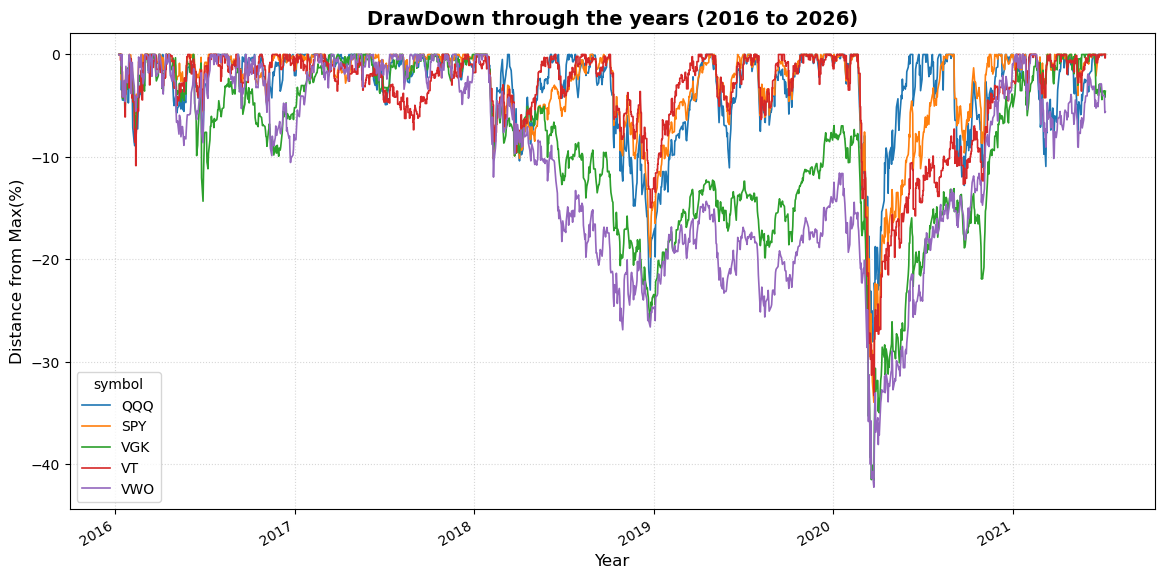

In [48]:
# First we realize the chart about the MaxDrawdawn to compare the ETFs
import matplotlib.pyplot as plt

prices['Date'] = pd.to_datetime(prices['Date'])

prices = prices.drop_duplicates(subset=['Date', 'symbol'])

prices = prices.sort_values(by='Date')

pivot_drawdown = prices.pivot(index='Date', columns='symbol', values='Drawdown')

pivot_drawdown = pivot_drawdown.ffill()

ax = pivot_drawdown.plot(figsize=(14, 7), linewidth=1.2)

ax.set_title('DrawDown through the years (2016 to 2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Distance from Max(%)', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.5)

plt.show()

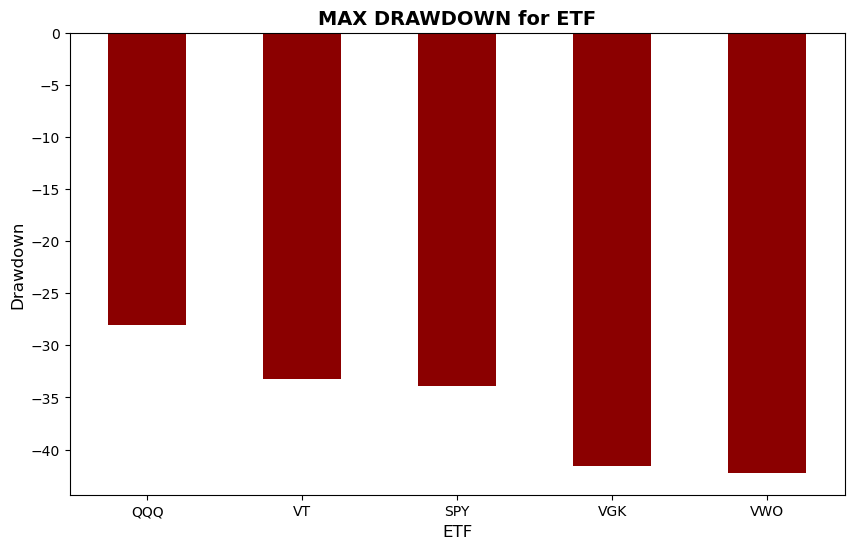

In [47]:
# WE realize the chart about the max drawdawn 
mdd_summary_ordered = mdd_summary.sort_values (by ='Max_Drawdown', ascending= False)
ax = mdd_summary_ordered.set_index ('symbol')['Max_Drawdown'].plot.bar(figsize=(10, 6), color='darkred')
ax.set_title('MAX DRAWDOWN for ETF', fontsize=14, fontweight='bold')
ax.set_xlabel('ETF', fontsize=12)
ax.set_ylabel('Drawdown', fontsize=12)
plt.xticks(rotation=0)
plt.show()

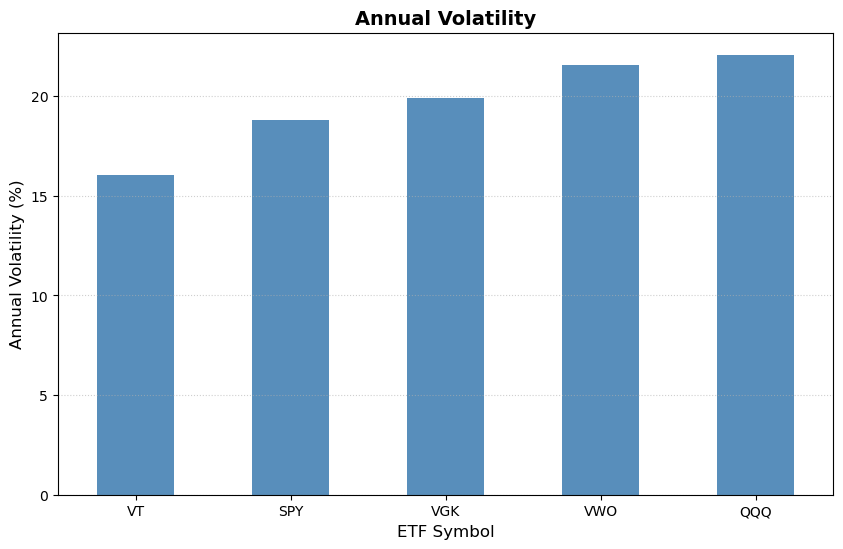

In [51]:
vol_ordered = etf_summary.sort_values (by='annual_Volatility',ascending=True)
ax3 = vol_ordered.set_index('symbol')['annual_Volatility'].plot.bar(figsize=(10, 6), color='steelblue', alpha=0.9)
ax3.set_title('Annual Volatility', fontsize=14, fontweight='bold')
ax3.set_xlabel('ETF Symbol', fontsize=12)
ax3.set_ylabel('Annual Volatility (%)', fontsize=12)
plt.xticks(rotation=0)                       
ax3.grid(axis='y', linestyle=':', alpha=0.6) 
plt.show()

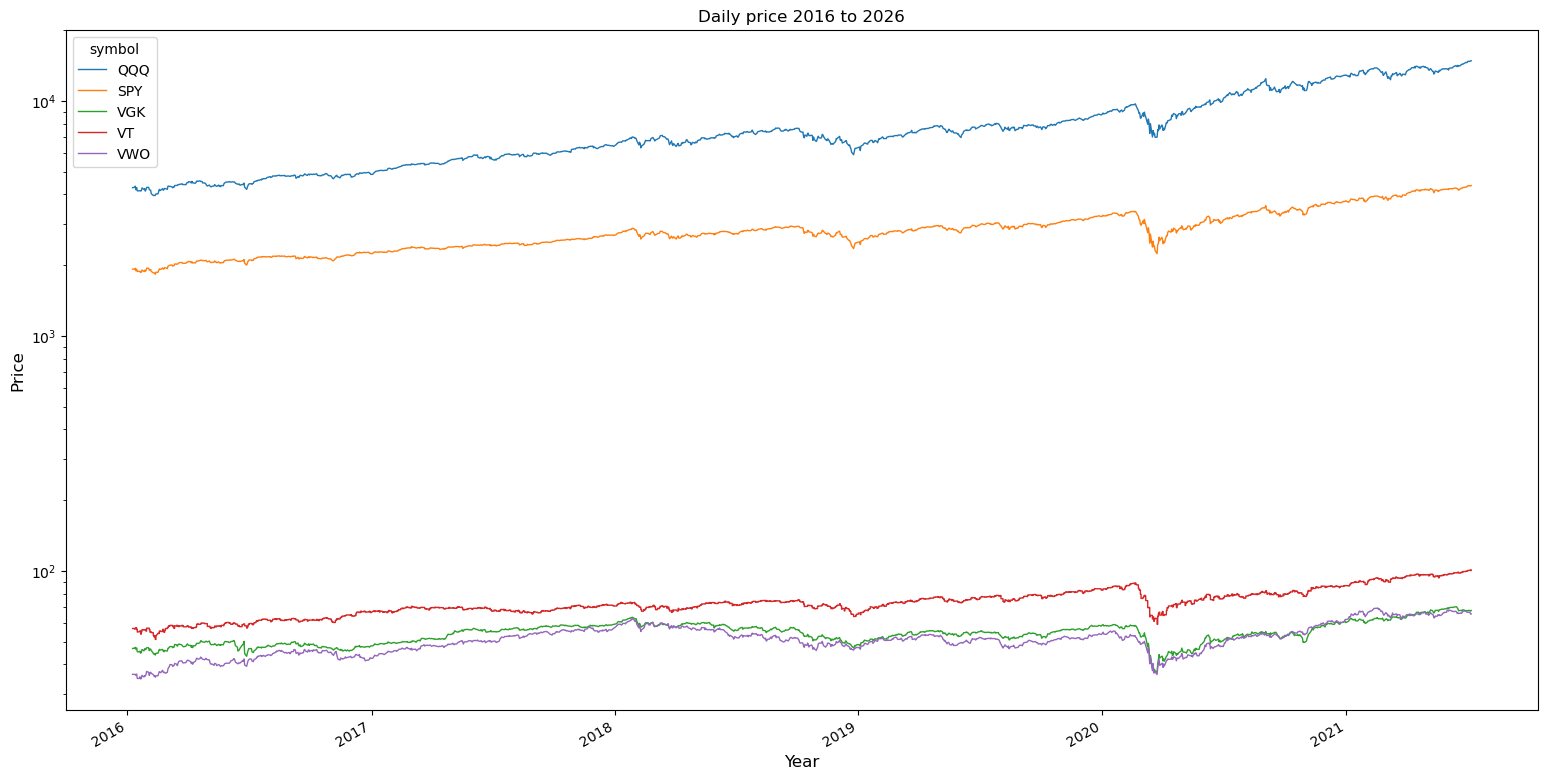

In [55]:
pivot_price = prices.pivot (index = 'Date', columns = 'symbol', values = 'Close')
pivot_price = pivot_price.ffill ()
ax = pivot_price.plot(figsize=(19, 10), linewidth=1.0)
ax.set_title ('Daily price 2016 to 2026')
ax.set_xlabel ('Year', fontsize = 12)
ax.set_ylabel('Price', fontsize=12)
ax.set_yscale('log')

plt.show()

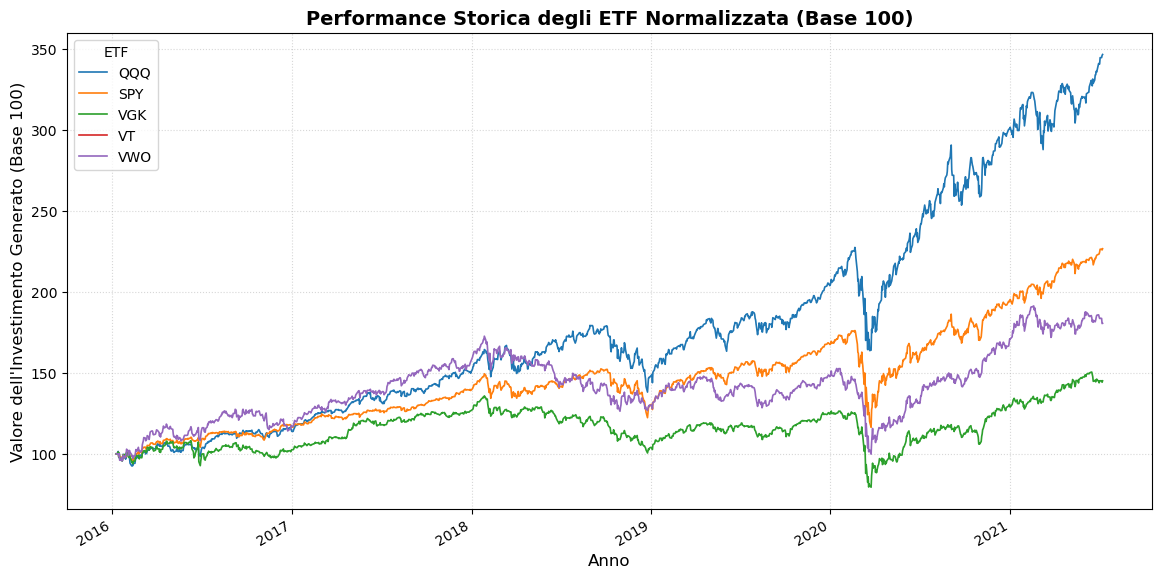

In [56]:
pivot_price = prices.pivot(index='Date', columns='symbol', values='Close')

pivot_price = pivot_price.ffill()
pivot_normalized = (pivot_price / pivot_price.iloc[0]) * 100
ax = pivot_normalized.plot(figsize=(14, 7), linewidth=1.2)
ax.set_title('Performance Storica degli ETF Normalizzata (Base 100)', fontsize=14, fontweight='bold')
ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Valore dell\'Investimento Generato (Base 100)', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.5)

ax.legend(title='ETF', loc='upper left')

plt.show()

In [58]:
nome_file_excel = "ETF_Analysis_Final_Report.xlsx"

# Salviamo il CSV storico pulito FUORI dal blocco Excel
prices.to_csv("etf_daily_historical_data.csv", index=False)

# 2. Apriamo lo strumento ExcelWriter di Pandas per inserire i fogli separati
with pd.ExcelWriter(nome_file_excel, engine='openpyxl') as writer:
    
    # Foglio 1: Dataset giornaliero completo
    prices.to_excel(writer, sheet_name="Dati_Storici_Giornalieri", index=False)
    
    # Foglio 2: Tabella riassuntiva dei KPI di Volatilità
    etf_summary.to_excel(writer, sheet_name="KPI_Volatilta", index=False)
    
    # Foglio 3: Tabella riassuntiva del Maximum Drawdown
    mdd_summary.to_excel(writer, sheet_name="KPI_Max_Drawdown", index=False)
    
    # Foglio 4: Tabella finale combinata (creata con i .merge())
    if 'final_summary' in locals():
        final_summary.to_excel(writer, sheet_name="Riepilogo_Performance_Totale", index=False)

print(f"🎉 Successo! Tutti i fogli sono stati salvati dentro il file: {nome_file_excel}")

<class 'ModuleNotFoundError'>: No module named 'openpyxl'